# Exploratory Data Analysis — RGBTDronePerson

Notebook phân tích dữ liệu phát hiện người từ drone trên hai modality **visible (RGB)** và **thermal**, theo thứ tự:

1. Dataset overview
2. Data quality check
3. Image resolution analysis
4. Class distribution
5. Bounding-box analysis
6. Spatial distribution
7. Pixel / intensity analysis

Mỗi phần đều có **Insight & đánh giá** được tính trực tiếp từ dữ liệu. Notebook không thay đổi bất kỳ file nào trong dataset.

## Thiết lập và quy ước

- Annotation chính: COCO JSON (`train_thermal.json`, `val_thermal.json`). Annotation này dùng chung tọa độ cho cặp visible–thermal đã căn chỉnh.
- Pascal VOC XML được dùng để kiểm tra sự hiện diện của label theo từng ảnh.
- `sample` trong báo cáo là một **cặp RGB–thermal** cùng tên file; số file ảnh vật lý bằng 2 lần số sample.
- Quét corrupt chạy trên toàn bộ ảnh. Phân tích pixel lấy mẫu ngẫu nhiên có seed cố định để giảm thời gian và bộ nhớ.

In [1]:
from pathlib import Path
import json
import warnings
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageFile
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=UserWarning)
ImageFile.LOAD_TRUNCATED_IMAGES = False
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
PIXEL_SAMPLE_PER_GROUP = 250   # mỗi split × modality
PIXEL_RESIZE = (128, 128)      # chỉ dùng cho thống kê pixel

def locate_dataset():
    candidates = [
        Path.cwd() / "RGBTDronePerson",
        Path.cwd(),
        Path.cwd().parent / "RGBTDronePerson",
    ]
    for p in candidates:
        if (p / "train_thermal.json").exists() and (p / "train").is_dir():
            return p.resolve()
    raise FileNotFoundError(
        "Không tìm thấy RGBTDronePerson. Hãy đặt notebook cạnh thư mục dataset "
        "hoặc chạy notebook từ bên trong thư mục dataset."
    )

DATA_ROOT = locate_dataset()
print(f"DATA_ROOT = {DATA_ROOT}")

Matplotlib is building the font cache; this may take a moment.


Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\GIANG\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


DATA_ROOT = G:\Capstone\code\Data\RGBTDronePerson


## 1. Dataset overview (số lượng mẫu train/val, số class, format)

In [2]:
SPLITS = {"train": "train_thermal.json", "val": "val_thermal.json"}
coco = {}
image_rows, ann_rows = [], []

for split, json_name in SPLITS.items():
    with open(DATA_ROOT / json_name, "r", encoding="utf-8") as f:
        data = json.load(f)
    coco[split] = data
    for im in data["images"]:
        image_rows.append({"split": split, **im})
    for ann in data["annotations"]:
        ann_rows.append({"split": split, **ann})

images_df = pd.DataFrame(image_rows)
anns_df = pd.DataFrame(ann_rows)

# Kiểm tra category map có nhất quán giữa các split không.
category_maps = {
    split: {c["id"]: c["name"] for c in data["categories"]}
    for split, data in coco.items()
}
assert len({tuple(sorted(m.items())) for m in category_maps.values()}) == 1, \
    "Category mapping không nhất quán giữa train và val"
CAT_MAP = category_maps["train"]
anns_df["class_name"] = anns_df["category_id"].map(CAT_MAP)

overview_rows = []
for split in SPLITS:
    n_samples = int((images_df["split"] == split).sum())
    overview_rows.append({
        "split": split,
        "paired_samples": n_samples,
        "visible_images": len(list((DATA_ROOT / split / "visible").glob("*"))),
        "thermal_images": len(list((DATA_ROOT / split / "thermal").glob("*"))),
        "xml_labels": len(list((DATA_ROOT / split / "annotation").glob("*.xml"))),
        "objects": int((anns_df["split"] == split).sum()),
        "objects/sample": (anns_df["split"] == split).sum() / n_samples,
    })
overview_df = pd.DataFrame(overview_rows).set_index("split")
display(overview_df)

format_df = pd.DataFrame({
    "Thành phần": ["Visible image", "Thermal image", "Annotation chính", "Annotation bổ sung"],
    "Vị trí / định dạng": [
        "<split>/visible/*.jpg",
        "<split>/thermal/*.jpg",
        "*_thermal.json — COCO: images, annotations, categories; bbox=[x,y,w,h]",
        "<split>/annotation/*.xml — Pascal VOC: xmin,ymin,xmax,ymax",
    ],
})
display(format_df)
print(f"Số class: {len(CAT_MAP)} — {CAT_MAP}")

,paired_samples,visible_images,thermal_images,xml_labels,objects,objects/sample
split,,,,,,
train,4900,4900,4900,4900,56314,11.493
val,1225,1225,1225,1225,14566,11.891


,Thành phần,Vị trí / định dạng
0,Visible image,<split>/visible/*.jpg
1,Thermal image,<split>/thermal/*.jpg
2,Annotation chính,"*_thermal.json — COCO: images, annotations, ca..."
3,Annotation bổ sung,"<split>/annotation/*.xml — Pascal VOC: xmin,ym..."


Số class: 4 — {0: 'person', 1: 'rider', 2: 'crowd', 3: 'uncertain'}


In [3]:
train_share = len(coco["train"]["images"]) / len(images_df)
pair_ok = (
    (overview_df["paired_samples"] == overview_df["visible_images"]) &
    (overview_df["paired_samples"] == overview_df["thermal_images"])
).all()
display(Markdown(
    "**Insight & đánh giá**\n\n"
    f"- Dataset có **{len(images_df):,} cặp ảnh** ({2*len(images_df):,} file ảnh): "
    f"{len(coco['train']['images']):,} train và {len(coco['val']['images']):,} val; "
    f"tỷ lệ train là **{train_share:.1%}**.\n"
    f"- Có **{len(CAT_MAP)} class**: {', '.join(CAT_MAP.values())}; "
    f"tổng **{len(anns_df):,} object**.\n"
    f"- Ghép cặp visible–thermal theo số lượng: **{'đầy đủ' if pair_ok else 'chưa đầy đủ'}**. "
    "COCO thuận tiện cho training/evaluation; XML hữu ích để đối chiếu chất lượng label."
))

**Insight & đánh giá**

- Dataset có **6,125 cặp ảnh** (12,250 file ảnh): 4,900 train và 1,225 val; tỷ lệ train là **80.0%**.
- Có **4 class**: person, rider, crowd, uncertain; tổng **70,880 object**.
- Ghép cặp visible–thermal theo số lượng: **đầy đủ**. COCO thuận tiện cho training/evaluation; XML hữu ích để đối chiếu chất lượng label.

## 2. Data quality check (corrupt, size, missing label, wrong bbox)

Các lỗi được kiểm tra:

- file ảnh thiếu, ảnh không đọc được/corrupt;
- kích thước thật khác metadata COCO, hoặc visible và thermal của cùng sample khác kích thước;
- thiếu XML, sample COCO không có object (được báo riêng vì có thể là ảnh âm hợp lệ), file ảnh/XML dư;
- bbox không hữu hạn, width/height không dương, vượt biên ảnh, category không tồn tại, hoặc `area` không bằng `w × h`.

In [4]:
def inspect_image(path):
    # Đọc header và verify cấu trúc file mà không giữ ảnh trong RAM.
    try:
        with Image.open(path) as im:
            width, height = im.size
            mode, fmt = im.mode, im.format
            im.verify()
        return {"readable": True, "actual_width": width, "actual_height": height,
                "mode": mode, "format": fmt, "error": None}
    except Exception as exc:
        return {"readable": False, "actual_width": np.nan, "actual_height": np.nan,
                "mode": None, "format": None, "error": f"{type(exc).__name__}: {exc}"}

quality_rows = []
for row in images_df.itertuples(index=False):
    for modality in ("visible", "thermal"):
        path = DATA_ROOT / row.split / modality / row.file_name
        base = {
            "split": row.split, "image_id": row.id, "file_name": row.file_name,
            "modality": modality, "path": str(path), "exists": path.is_file(),
            "meta_width": row.width, "meta_height": row.height,
        }
        base.update(inspect_image(path) if path.is_file() else {
            "readable": False, "actual_width": np.nan, "actual_height": np.nan,
            "mode": None, "format": None, "error": "missing file",
        })
        quality_rows.append(base)

quality_df = pd.DataFrame(quality_rows)
quality_df["size_mismatch_metadata"] = (
    quality_df["readable"] &
    ((quality_df["actual_width"] != quality_df["meta_width"]) |
     (quality_df["actual_height"] != quality_df["meta_height"]))
)

# Đối chiếu kích thước của hai modality theo cùng sample.
pair_sizes = quality_df.pivot_table(
    index=["split", "image_id", "file_name"], columns="modality",
    values=["actual_width", "actual_height"], aggfunc="first"
)
pair_size_mismatch = (
    (pair_sizes[("actual_width", "visible")] != pair_sizes[("actual_width", "thermal")]) |
    (pair_sizes[("actual_height", "visible")] != pair_sizes[("actual_height", "thermal")])
).fillna(True)

# Missing và orphan files.
file_audit = []
for split in SPLITS:
    expected_img = set(images_df.loc[images_df["split"].eq(split), "file_name"])
    expected_xml = {Path(x).with_suffix(".xml").name for x in expected_img}
    actual_xml = {p.name for p in (DATA_ROOT / split / "annotation").glob("*.xml")}
    for modality in ("visible", "thermal"):
        actual_img = {p.name for p in (DATA_ROOT / split / modality).glob("*") if p.is_file()}
        file_audit.append({
            "split": split, "component": modality,
            "missing": len(expected_img - actual_img), "orphan": len(actual_img - expected_img),
        })
    file_audit.append({
        "split": split, "component": "XML label",
        "missing": len(expected_xml - actual_xml), "orphan": len(actual_xml - expected_xml),
    })
file_audit_df = pd.DataFrame(file_audit)

ann_counts = anns_df.groupby(["split", "image_id"]).size()
empty_coco = images_df.set_index(["split", "id"]).index.difference(ann_counts.index)

quality_summary = pd.DataFrame({
    "metric": [
        "Expected image files", "Missing image files", "Unreadable/corrupt images",
        "Size mismatch vs COCO", "Visible–thermal pair size mismatch",
        "Missing XML labels", "Orphan image files", "Orphan XML labels",
        "COCO samples with 0 objects",
    ],
    "count": [
        len(quality_df), (~quality_df["exists"]).sum(),
        (quality_df["exists"] & ~quality_df["readable"]).sum(),
        quality_df["size_mismatch_metadata"].sum(), pair_size_mismatch.sum(),
        file_audit_df.loc[file_audit_df["component"].eq("XML label"), "missing"].sum(),
        file_audit_df.loc[file_audit_df["component"].isin(["visible", "thermal"]), "orphan"].sum(),
        file_audit_df.loc[file_audit_df["component"].eq("XML label"), "orphan"].sum(),
        len(empty_coco),
    ],
})
display(quality_summary)
display(file_audit_df)

,metric,count
0,Expected image files,12250
1,Missing image files,0
2,Unreadable/corrupt images,0
3,Size mismatch vs COCO,6
4,Visible–thermal pair size mismatch,0
5,Missing XML labels,0
6,Orphan image files,0
7,Orphan XML labels,0
8,COCO samples with 0 objects,7


,split,component,missing,orphan
0,train,visible,0,0
1,train,thermal,0,0
2,train,XML label,0,0
3,val,visible,0,0
4,val,thermal,0,0
5,val,XML label,0,0


In [5]:
# Vector hóa kiểm tra bbox bằng kích thước metadata của ảnh.
img_dims = images_df[["split", "id", "width", "height"]].rename(
    columns={"id": "image_id", "width": "image_width", "height": "image_height"}
)
bbox_df = anns_df.merge(img_dims, on=["split", "image_id"], how="left", validate="many_to_one")
bbox_arr = pd.DataFrame(bbox_df["bbox"].tolist(), columns=["x", "y", "bbox_w", "bbox_h"], index=bbox_df.index)
bbox_df = pd.concat([bbox_df, bbox_arr], axis=1)

finite = np.isfinite(bbox_df[["x", "y", "bbox_w", "bbox_h"]]).all(axis=1)
bbox_df["non_finite"] = ~finite
bbox_df["non_positive_size"] = (bbox_df["bbox_w"] <= 0) | (bbox_df["bbox_h"] <= 0)
bbox_df["outside_image"] = (
    (bbox_df["x"] < 0) | (bbox_df["y"] < 0) |
    (bbox_df["x"] + bbox_df["bbox_w"] > bbox_df["image_width"] + 1e-6) |
    (bbox_df["y"] + bbox_df["bbox_h"] > bbox_df["image_height"] + 1e-6)
)
bbox_df["unknown_category"] = ~bbox_df["category_id"].isin(CAT_MAP)
bbox_df["area_mismatch"] = ~np.isclose(
    bbox_df["area"].astype(float), bbox_df["bbox_w"] * bbox_df["bbox_h"], rtol=0, atol=1e-6
)

bbox_checks = ["non_finite", "non_positive_size", "outside_image", "unknown_category", "area_mismatch"]
bbox_quality = pd.DataFrame({
    "check": bbox_checks,
    "count": [int(bbox_df[c].sum()) for c in bbox_checks],
})
display(bbox_quality)

bad_bbox_mask = bbox_df[["non_finite", "non_positive_size", "outside_image", "unknown_category"]].any(axis=1)
if bad_bbox_mask.any():
    display(bbox_df.loc[bad_bbox_mask, ["split", "image_id", "bbox", "class_name"] + bbox_checks].head(20))

,check,count
0,non_finite,0
1,non_positive_size,1
2,outside_image,0
3,unknown_category,0
4,area_mismatch,0


,split,image_id,bbox,class_name,non_finite,non_positive_size,outside_image,unknown_category,area_mismatch
562,train,76,"[629, 187, 0, 9]",person,False,True,False,False,False


In [6]:
n_corrupt = int((quality_df["exists"] & ~quality_df["readable"]).sum())
n_missing_img = int((~quality_df["exists"]).sum())
n_size = int(quality_df["size_mismatch_metadata"].sum())
n_missing_xml = int(file_audit_df.loc[file_audit_df["component"].eq("XML label"), "missing"].sum())
n_bad_bbox = int(bad_bbox_mask.sum())
status = "TỐT" if (n_corrupt + n_missing_img + n_size + n_missing_xml + n_bad_bbox) == 0 else "CẦN XỬ LÝ"
display(Markdown(
    "**Insight & đánh giá**\n\n"
    f"- Trạng thái tổng quát: **{status}**. Thiếu ảnh: **{n_missing_img}**; corrupt: **{n_corrupt}**; "
    f"sai kích thước metadata: **{n_size}**; thiếu XML: **{n_missing_xml}**.\n"
    f"- Có **{n_bad_bbox}** bbox lỗi hình học/category trên {len(bbox_df):,} bbox; "
    f"**{int(bbox_df['area_mismatch'].sum())}** bbox có trường `area` lệch `w×h`.\n"
    f"- **{len(empty_coco)}** sample không có object trong COCO. Đây không nhất thiết là lỗi: "
    "có thể là ảnh âm; cần giữ nếu pipeline detector hỗ trợ negative images."
))

**Insight & đánh giá**

- Trạng thái tổng quát: **CẦN XỬ LÝ**. Thiếu ảnh: **0**; corrupt: **0**; sai kích thước metadata: **6**; thiếu XML: **0**.
- Có **1** bbox lỗi hình học/category trên 70,880 bbox; **0** bbox có trường `area` lệch `w×h`.
- **7** sample không có object trong COCO. Đây không nhất thiết là lỗi: có thể là ảnh âm; cần giữ nếu pipeline detector hỗ trợ negative images.

## 3. Image Resolution Analysis (histogram width/height, aspect ratio)

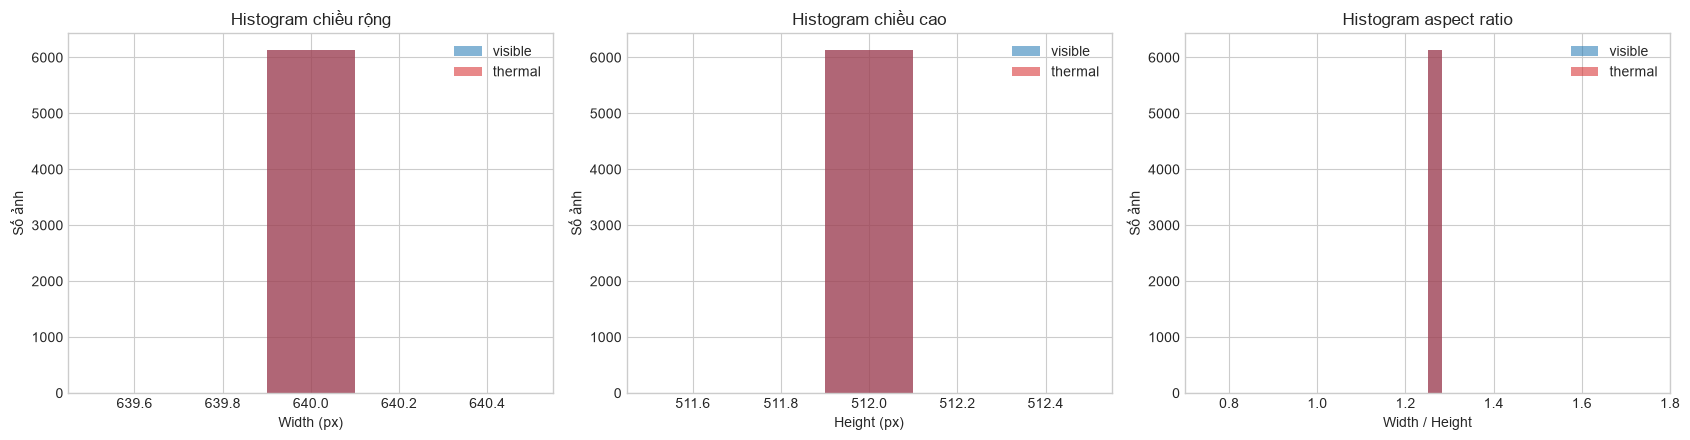

images  width_min  width_median  width_max  height_min  \
split modality                                                           
train thermal     4900        640       640.000        640         512   
      visible     4900        640       640.000        640         512   
val   thermal     1225        640       640.000        640         512   
      visible     1225        640       640.000        640         512   

                height_median  height_max  aspect_mean  aspect_std  \
split modality                                                       
train thermal         512.000         512        1.250       0.000   
      visible         512.000         512        1.250       0.000   
val   thermal         512.000         512        1.250       0.000   
      visible         512.000         512        1.250       0.000   

                unique_resolutions  
split modality                      
train thermal                    1  
      visible                    1  
val   thermal                    1  
      visible                    1

,,count
modality,resolution,
thermal,640×512,6125
visible,640×512,6125


In [7]:
valid_quality = quality_df[quality_df["readable"]].copy()
valid_quality["aspect_ratio"] = valid_quality["actual_width"] / valid_quality["actual_height"]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for (modality, color) in [("visible", "tab:blue"), ("thermal", "tab:red")]:
    q = valid_quality[valid_quality["modality"].eq(modality)]
    axes[0].hist(q["actual_width"], bins=min(30, max(5, q["actual_width"].nunique() * 2)),
                 alpha=.55, label=modality, color=color)
    axes[1].hist(q["actual_height"], bins=min(30, max(5, q["actual_height"].nunique() * 2)),
                 alpha=.55, label=modality, color=color)
    axes[2].hist(q["aspect_ratio"], bins=30, alpha=.55, label=modality, color=color)
axes[0].set(title="Histogram chiều rộng", xlabel="Width (px)", ylabel="Số ảnh")
axes[1].set(title="Histogram chiều cao", xlabel="Height (px)", ylabel="Số ảnh")
axes[2].set(title="Histogram aspect ratio", xlabel="Width / Height", ylabel="Số ảnh")
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

resolution_summary = (valid_quality
    .groupby(["split", "modality"])
    .agg(images=("file_name", "size"), width_min=("actual_width", "min"),
         width_median=("actual_width", "median"), width_max=("actual_width", "max"),
         height_min=("actual_height", "min"), height_median=("actual_height", "median"),
         height_max=("actual_height", "max"), aspect_mean=("aspect_ratio", "mean"),
         aspect_std=("aspect_ratio", "std"), unique_resolutions=("aspect_ratio", "size"))
)
# Ghi đè bằng số cặp (width, height) khác nhau.
unique_res = valid_quality.groupby(["split", "modality"]).apply(
    lambda d: d[["actual_width", "actual_height"]].drop_duplicates().shape[0],
    include_groups=False,
)
resolution_summary["unique_resolutions"] = unique_res
display(resolution_summary)

res_counts = (valid_quality.assign(
    resolution=valid_quality["actual_width"].astype(int).astype(str) + "×" +
               valid_quality["actual_height"].astype(int).astype(str))
    .groupby(["modality", "resolution"]).size().rename("count")
    .sort_values(ascending=False).groupby(level=0).head(10).to_frame())
display(res_counts)

In [8]:
mode_res = (valid_quality.assign(
    resolution=valid_quality["actual_width"].astype(int).astype(str) + "×" +
               valid_quality["actual_height"].astype(int).astype(str))
    .groupby("modality")["resolution"].agg(lambda s: s.value_counts().index[0]))
mode_share = (valid_quality.assign(
    resolution=valid_quality["actual_width"].astype(int).astype(str) + "×" +
               valid_quality["actual_height"].astype(int).astype(str))
    .groupby("modality")["resolution"].agg(lambda s: s.value_counts(normalize=True).iloc[0]))
display(Markdown(
    "**Insight & đánh giá**\n\n"
    f"- Resolution phổ biến nhất: visible **{mode_res.get('visible', 'N/A')}** "
    f"({mode_share.get('visible', np.nan):.1%}), thermal **{mode_res.get('thermal', 'N/A')}** "
    f"({mode_share.get('thermal', np.nan):.1%}).\n"
    f"- Aspect ratio trung bình toàn bộ là **{valid_quality['aspect_ratio'].mean():.3f}** "
    f"(std **{valid_quality['aspect_ratio'].std():.3f}**). "
    "Nếu số resolution ít, resize/letterbox ổn định; nếu đa dạng, nên giữ aspect ratio và padding để tránh méo người."
))

**Insight & đánh giá**

- Resolution phổ biến nhất: visible **640×512** (100.0%), thermal **640×512** (100.0%).
- Aspect ratio trung bình toàn bộ là **1.250** (std **0.000**). Nếu số resolution ít, resize/letterbox ổn định; nếu đa dạng, nên giữ aspect ratio và padding để tránh méo người.

## 4. Class distribution (số lượng object mỗi class)

split,train,val,total,percent
class_name,,,,
person,43169,11009,54178,76.436
crowd,7172,2004,9176,12.946
rider,4633,1447,6080,8.578
uncertain,1340,106,1446,2.040


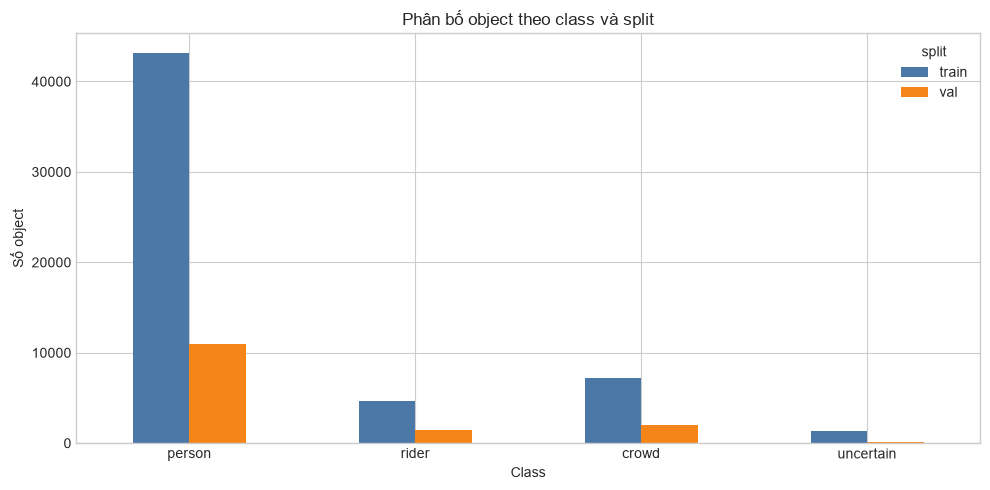

**Insight & đánh giá**

- Class nhiều nhất là **person** (54,178; 76.4%), ít nhất là **uncertain** (1,446; 2.0%).
- Tỷ lệ mất cân bằng max/min là **37.5×**. Nên cân nhắc class-weight, focal loss hoặc sampler cân bằng; báo cáo AP theo từng class.

In [9]:
class_dist = (bbox_df.groupby(["class_name", "split"]).size()
              .unstack(fill_value=0).reindex(list(CAT_MAP.values())))
class_dist["total"] = class_dist.sum(axis=1)
class_dist["percent"] = class_dist["total"] / class_dist["total"].sum() * 100
display(class_dist.sort_values("total", ascending=False))

plot_df = class_dist.drop(columns=["total", "percent"])
ax = plot_df.plot(kind="bar", figsize=(10, 5), color=["#4C78A8", "#F58518"])
ax.set(title="Phân bố object theo class và split", xlabel="Class", ylabel="Số object")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

nonzero = class_dist.loc[class_dist["total"] > 0, "total"]
imbalance_ratio = nonzero.max() / nonzero.min()
largest = class_dist["total"].idxmax(); smallest = class_dist["total"].idxmin()
display(Markdown(
    "**Insight & đánh giá**\n\n"
    f"- Class nhiều nhất là **{largest}** ({int(class_dist.loc[largest, 'total']):,}; "
    f"{class_dist.loc[largest, 'percent']:.1f}%), ít nhất là **{smallest}** "
    f"({int(class_dist.loc[smallest, 'total']):,}; {class_dist.loc[smallest, 'percent']:.1f}%).\n"
    f"- Tỷ lệ mất cân bằng max/min là **{imbalance_ratio:.1f}×**. "
    + ("Nên cân nhắc class-weight, focal loss hoặc sampler cân bằng; báo cáo AP theo từng class."
       if imbalance_ratio >= 3 else "Mức mất cân bằng không quá mạnh, nhưng vẫn nên báo cáo AP theo từng class.")
))

## 5. Bounding box (small/medium/large, aspect ratio bbox, số object mỗi ảnh)

Quy ước kích thước theo COCO trên **diện tích pixel tuyệt đối**:

- small: area `< 32²`;
- medium: `32² ≤ area < 96²`;
- large: area `≥ 96²`.

Đây là ngưỡng tham chiếu phổ biến. Với ảnh drone, bảng `area_ratio` (diện tích bbox / diện tích ảnh) cũng được cung cấp để đánh giá độc lập với resolution.

split,train,val,total,percent
size_group,,,,
small,56257,14532,70789,99.872
medium,57,34,91,0.128
large,0,0,0,0.000


,count,mean,std,min,50%,75%,90%,95%,99%,max
split,,,,,,,,,,
train,"4,900.000",11.493,12.400,0.000,7.000,16.000,28.000,38.000,57.010,80.000
val,"1,225.000",11.891,16.755,1.000,7.000,13.000,24.000,42.000,87.000,98.000


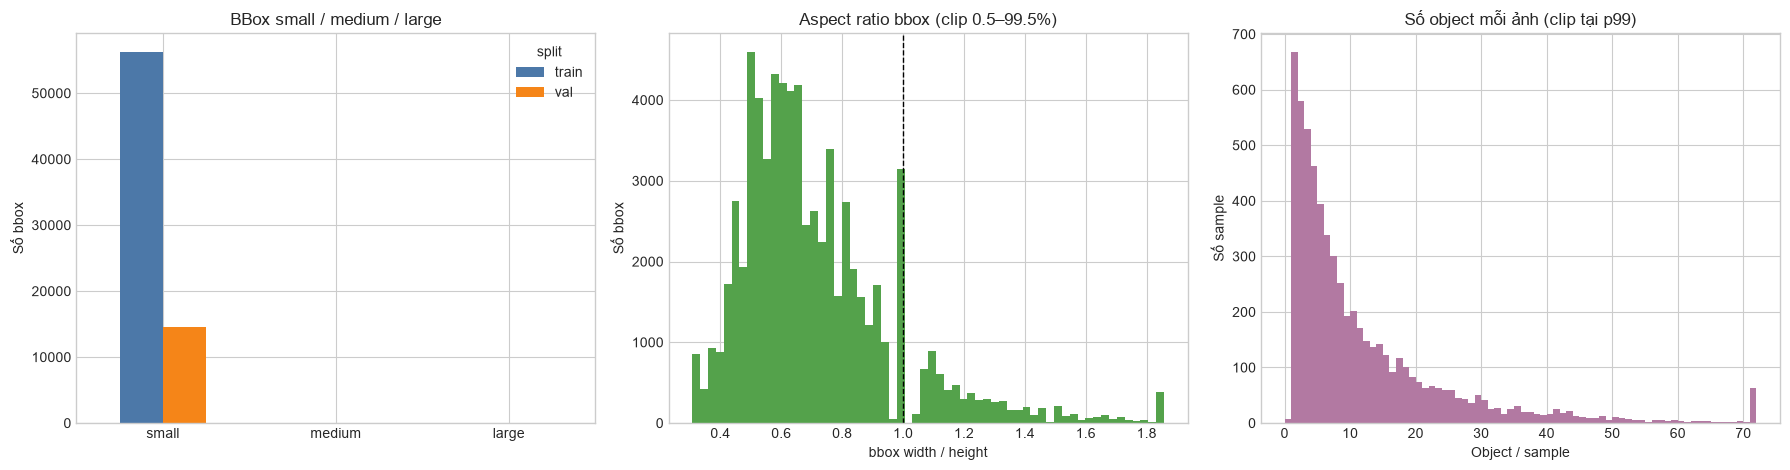

,count,mean,std,min,1%,25%,50%,75%,90%,95%,99%,max
bbox_w,"70,880.000",9.886,3.747,0.000,4.000,7.000,9.000,11.000,14.000,17.000,22.000,84.000
bbox_h,"70,880.000",14.228,3.943,1.000,7.000,12.000,14.000,16.000,19.000,21.000,26.000,71.000
bbox_area,"70,880.000",147.433,102.628,0.000,36.000,91.000,126.000,176.000,240.000,300.000,483.000,"4,347.000"
area_ratio,"70,880.000",0.000,0.000,0.000,0.000,0.000,0.000,0.001,0.001,0.001,0.001,0.013
bbox_aspect_ratio,"70,880.000",0.717,0.267,0.000,0.333,0.538,0.667,0.824,1.000,1.214,1.667,6.444


In [10]:
bbox_df["bbox_area"] = bbox_df["bbox_w"] * bbox_df["bbox_h"]
bbox_df["area_ratio"] = bbox_df["bbox_area"] / (bbox_df["image_width"] * bbox_df["image_height"])
bbox_df["bbox_aspect_ratio"] = bbox_df["bbox_w"] / bbox_df["bbox_h"]
bbox_df["size_group"] = pd.cut(
    bbox_df["bbox_area"], bins=[-np.inf, 32**2, 96**2, np.inf],
    labels=["small", "medium", "large"], right=False
)

size_dist = (bbox_df.groupby(["size_group", "split"], observed=False).size()
             .unstack(fill_value=0).reindex(["small", "medium", "large"]))
size_dist["total"] = size_dist.sum(axis=1)
size_dist["percent"] = size_dist["total"] / size_dist["total"].sum() * 100
display(size_dist)

objects_per_image = (images_df[["split", "id"]].rename(columns={"id": "image_id"})
    .merge(bbox_df.groupby(["split", "image_id"]).size().rename("objects").reset_index(),
           on=["split", "image_id"], how="left"))
objects_per_image["objects"] = objects_per_image["objects"].fillna(0).astype(int)
display(objects_per_image.groupby("split")["objects"].describe(percentiles=[.5, .75, .9, .95, .99]))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
size_dist[[c for c in ["train", "val"] if c in size_dist]].plot(
    kind="bar", ax=axes[0], color=["#4C78A8", "#F58518"])
axes[0].set(title="BBox small / medium / large", xlabel="", ylabel="Số bbox")
axes[0].tick_params(axis="x", rotation=0)

ratio_clip = bbox_df["bbox_aspect_ratio"].clip(
    bbox_df["bbox_aspect_ratio"].quantile(.005), bbox_df["bbox_aspect_ratio"].quantile(.995))
axes[1].hist(ratio_clip, bins=60, color="#54A24B")
axes[1].axvline(1, color="black", linestyle="--", linewidth=1)
axes[1].set(title="Aspect ratio bbox (clip 0.5–99.5%)", xlabel="bbox width / height", ylabel="Số bbox")

max_show = max(10, int(objects_per_image["objects"].quantile(.99)))
axes[2].hist(objects_per_image["objects"].clip(upper=max_show), bins=range(max_show + 2), color="#B279A2")
axes[2].set(title="Số object mỗi ảnh (clip tại p99)", xlabel="Object / sample", ylabel="Số sample")
plt.tight_layout(); plt.show()

bbox_stats = bbox_df[["bbox_w", "bbox_h", "bbox_area", "area_ratio", "bbox_aspect_ratio"]].describe(
    percentiles=[.01, .25, .5, .75, .9, .95, .99]).T
display(bbox_stats)

In [11]:
small_share = (bbox_df["size_group"] == "small").mean()
median_area_ratio = bbox_df["area_ratio"].median()
median_obj = objects_per_image["objects"].median()
p95_obj = objects_per_image["objects"].quantile(.95)
median_ar = bbox_df["bbox_aspect_ratio"].median()
display(Markdown(
    "**Insight & đánh giá**\n\n"
    f"- **{small_share:.1%}** bbox thuộc nhóm small theo COCO; bbox trung vị chỉ chiếm "
    f"**{median_area_ratio:.3%}** diện tích ảnh. Đây là bài toán **small-object detection** "
    "nếu tỷ lệ small chiếm ưu thế.\n"
    f"- Aspect ratio bbox trung vị **{median_ar:.2f}** (w/h). Giá trị rất xa 1 phản ánh "
    "hình người/rider kéo dài hoặc label crowd rộng; augmentation không nên làm méo tỷ lệ quá mạnh.\n"
    f"- Trung vị **{median_obj:.0f} object/ảnh**, p95 **{p95_obj:.0f}**. "
    "Ảnh đông đối tượng cần giới hạn max detections đủ lớn và NMS phù hợp để tránh bỏ sót."
))

**Insight & đánh giá**

- **99.9%** bbox thuộc nhóm small theo COCO; bbox trung vị chỉ chiếm **0.038%** diện tích ảnh. Đây là bài toán **small-object detection** nếu tỷ lệ small chiếm ưu thế.
- Aspect ratio bbox trung vị **0.67** (w/h). Giá trị rất xa 1 phản ánh hình người/rider kéo dài hoặc label crowd rộng; augmentation không nên làm méo tỷ lệ quá mạnh.
- Trung vị **7 object/ảnh**, p95 **38**. Ảnh đông đối tượng cần giới hạn max detections đủ lớn và NMS phù hợp để tránh bỏ sót.

## 6. Spatial distribution (object tập trung ở center hay edge)

Tâm bbox được chuẩn hóa về `[0,1]`. **Center** là ô giữa của lưới 3×3 (`1/3 ≤ x,y < 2/3`); mọi vị trí còn lại được xem là **edge**. Heatmap và bảng 3×3 giúp nhận diện bias vị trí chi tiết hơn.

split,train,val,All,percent_all
spatial_zone,,,,
center,10452,3502,13954,19.687
edge,45862,11064,56926,80.313
All,56314,14566,70880,100.000


grid_col,left,center,right
grid_row,,,
top,8.03%,12.73%,8.49%
middle,9.75%,19.69%,11.16%
bottom,8.01%,13.97%,8.16%


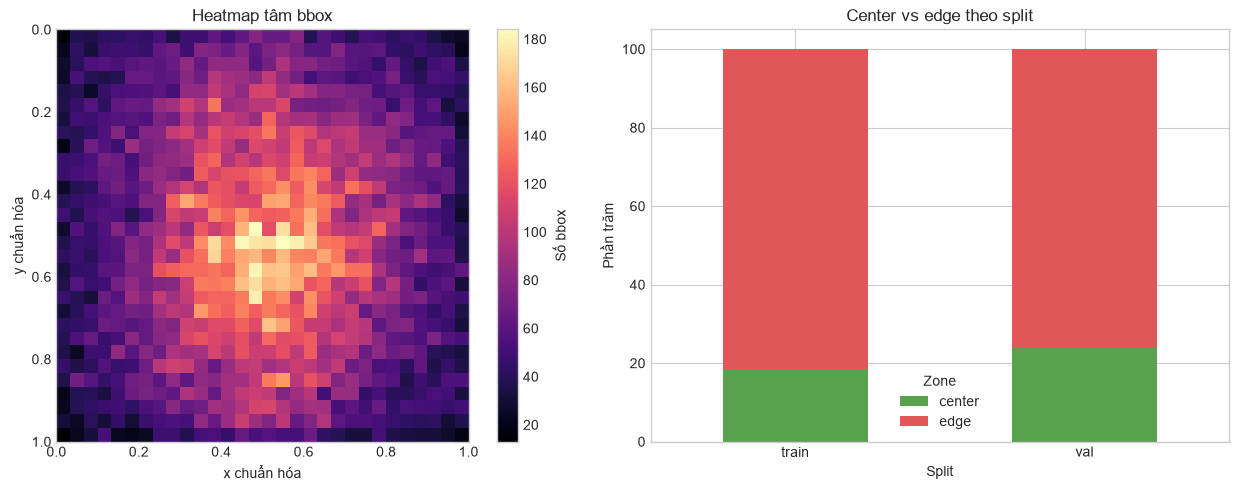

In [12]:
bbox_df["cx_norm"] = (bbox_df["x"] + bbox_df["bbox_w"] / 2) / bbox_df["image_width"]
bbox_df["cy_norm"] = (bbox_df["y"] + bbox_df["bbox_h"] / 2) / bbox_df["image_height"]
bbox_df["spatial_zone"] = np.where(
    bbox_df["cx_norm"].between(1/3, 2/3, inclusive="left") &
    bbox_df["cy_norm"].between(1/3, 2/3, inclusive="left"), "center", "edge"
)
bbox_df["grid_col"] = pd.cut(bbox_df["cx_norm"], [0, 1/3, 2/3, 1],
                              labels=["left", "center", "right"], include_lowest=True)
bbox_df["grid_row"] = pd.cut(bbox_df["cy_norm"], [0, 1/3, 2/3, 1],
                              labels=["top", "middle", "bottom"], include_lowest=True)

zone_table = pd.crosstab(bbox_df["spatial_zone"], bbox_df["split"], margins=True)
zone_table["percent_all"] = zone_table["All"] / zone_table.loc["All", "All"] * 100
display(zone_table)

grid = pd.crosstab(bbox_df["grid_row"], bbox_df["grid_col"], normalize=True) * 100
grid = grid.reindex(index=["top", "middle", "bottom"], columns=["left", "center", "right"])
display(grid.style.format("{:.2f}%").background_gradient(cmap="YlOrRd"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
h = axes[0].hist2d(bbox_df["cx_norm"], bbox_df["cy_norm"], bins=30, range=[[0,1],[0,1]], cmap="magma")
axes[0].invert_yaxis(); axes[0].set_aspect("equal")
axes[0].set(title="Heatmap tâm bbox", xlabel="x chuẩn hóa", ylabel="y chuẩn hóa")
plt.colorbar(h[3], ax=axes[0], label="Số bbox")

zone_by_split = pd.crosstab(bbox_df["split"], bbox_df["spatial_zone"], normalize="index") * 100
zone_by_split[[c for c in ["center", "edge"] if c in zone_by_split]].plot(
    kind="bar", stacked=True, ax=axes[1], color=["#59A14F", "#E15759"])
axes[1].set(title="Center vs edge theo split", xlabel="Split", ylabel="Phần trăm")
axes[1].tick_params(axis="x", rotation=0); axes[1].legend(title="Zone")
plt.tight_layout(); plt.show()

In [13]:
center_share = bbox_df["spatial_zone"].eq("center").mean()
peak_cell = grid.stack().idxmax(); peak_value = grid.stack().max()
center_expected_uniform = 1/9
display(Markdown(
    "**Insight & đánh giá**\n\n"
    f"- **{center_share:.1%}** tâm object nằm trong ô center (diện tích ô bằng 11.1% ảnh); "
    f"phân bố đều theo diện tích sẽ cho khoảng **{center_expected_uniform:.1%}**.\n"
    f"- Ô tập trung nhất là **{peak_cell[0]}–{peak_cell[1]}** với **{peak_value:.1f}%** object. "
    + ("Có dấu hiệu center bias; nên dùng random crop/translation có kiểm soát và kiểm tra AP theo vùng."
       if center_share > center_expected_uniform * 1.5 else
       "Center bias không quá mạnh theo ngưỡng này; vẫn nên giữ augmentation dịch chuyển để tăng tính bền vững ở mép ảnh.")
))

**Insight & đánh giá**

- **19.7%** tâm object nằm trong ô center (diện tích ô bằng 11.1% ảnh); phân bố đều theo diện tích sẽ cho khoảng **11.1%**.
- Ô tập trung nhất là **middle–center** với **19.7%** object. Có dấu hiệu center bias; nên dùng random crop/translation có kiểm soát và kiểm tra AP theo vùng.

## 7. Pixel / intensity (histogram RGB, mean/std, brightness/contrast)

Mỗi nhóm split × modality lấy tối đa `PIXEL_SAMPLE_PER_GROUP` ảnh bằng seed cố định. Ảnh được resize về 128×128 chỉ để thống kê phân bố pixel. Với thermal, ảnh được đọc thành 3 kênh để phát hiện thermal grayscale (ba histogram trùng nhau) hoặc thermal đã colorize.

- **Brightness**: mean luminance `0.2126R + 0.7152G + 0.0722B`.
- **Contrast**: standard deviation của luminance trong từng ảnh.

Đã lấy mẫu 1,000 ảnh cho phân tích pixel.


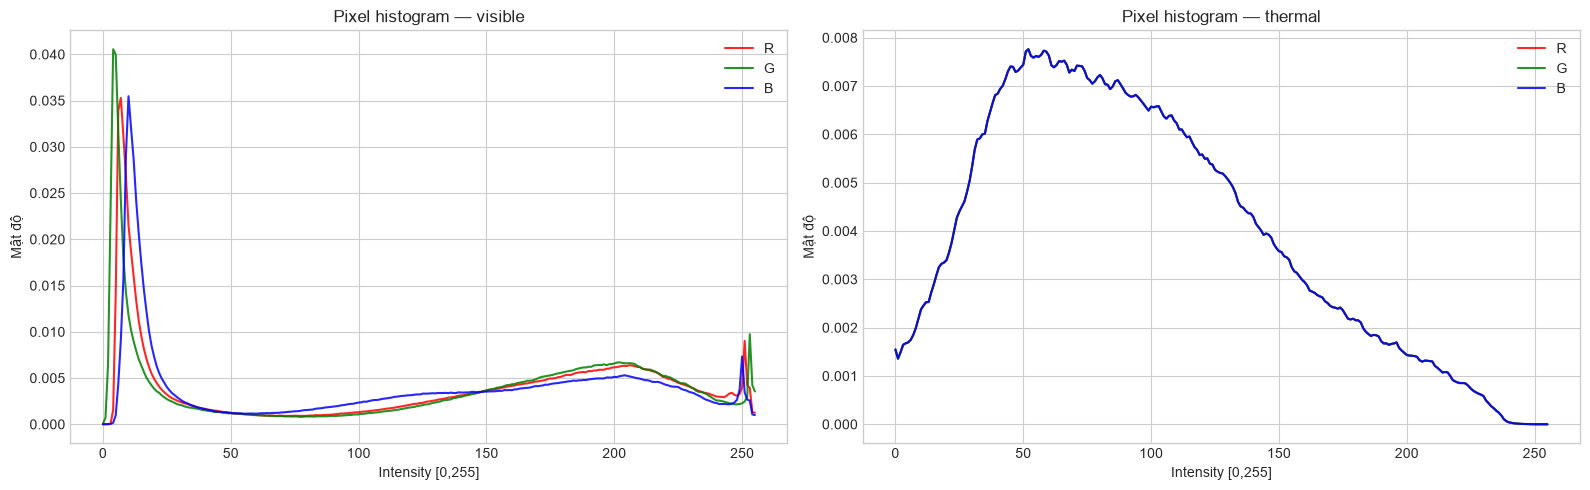

sampled_images  mean_R  mean_G  mean_B  std_R  std_G  std_B  \
split modality                                                                
train thermal              250  95.460  95.460  95.460 42.627 42.627 42.627   
      visible              250 119.539 119.086 112.828 36.783 36.352 37.374   
val   thermal              250  91.760  91.760  91.760 48.213 48.213 48.213   
      visible              250 128.936 128.735 118.512 35.034 31.797 35.084   

                brightness_mean  brightness_std  contrast_mean  contrast_std  \
split modality                                                                 
train thermal            95.460          20.243         42.627         9.395   
      visible           118.730          77.794         36.158        13.233   
val   thermal            91.760          20.929         48.213        13.704   
      visible           128.039          79.873         32.245        11.136   

                channel_delta_mean  
split modality                      
train thermal                0.000  
      visible                8.529  
val   thermal                0.000  
      visible               13.450

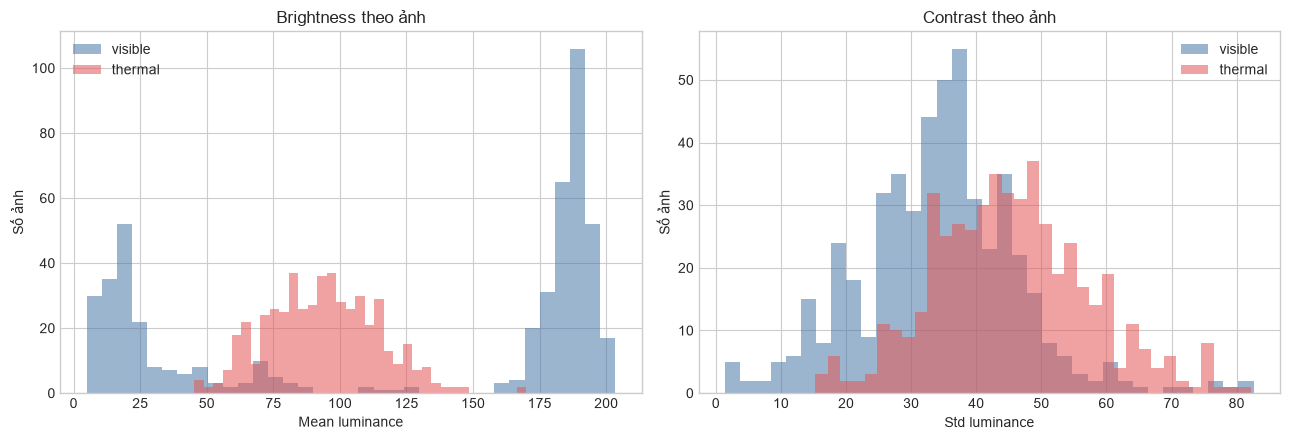

In [14]:
rng = np.random.default_rng(SEED)
pixel_rows = []
histograms = {}

for split in SPLITS:
    for modality in ("visible", "thermal"):
        paths = quality_df.loc[
            quality_df["split"].eq(split) & quality_df["modality"].eq(modality) & quality_df["readable"],
            "path"
        ].to_numpy()
        n = min(PIXEL_SAMPLE_PER_GROUP, len(paths))
        chosen = rng.choice(paths, size=n, replace=False)
        hist = np.zeros((3, 256), dtype=np.int64)
        for path in chosen:
            with Image.open(path) as im:
                arr = np.asarray(im.convert("RGB").resize(PIXEL_RESIZE), dtype=np.uint8)
            flat = arr.reshape(-1, 3)
            for c in range(3):
                hist[c] += np.bincount(flat[:, c], minlength=256)
            channel_mean = flat.mean(axis=0)
            channel_std = flat.std(axis=0)
            luminance = (arr[..., 0] * 0.2126 + arr[..., 1] * 0.7152 + arr[..., 2] * 0.0722)
            pixel_rows.append({
                "split": split, "modality": modality, "file_name": Path(path).name,
                "mean_R": channel_mean[0], "mean_G": channel_mean[1], "mean_B": channel_mean[2],
                "std_R": channel_std[0], "std_G": channel_std[1], "std_B": channel_std[2],
                "brightness": luminance.mean(), "contrast": luminance.std(),
                "channel_delta": np.ptp(channel_mean),
            })
        histograms[(split, modality)] = hist

pixel_df = pd.DataFrame(pixel_rows)
print(f"Đã lấy mẫu {len(pixel_df):,} ảnh cho phân tích pixel.")

# Cộng train + val để biểu đồ dễ đọc.
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
colors = ["red", "green", "blue"]
for ax, modality in zip(axes, ["visible", "thermal"]):
    hist = sum(histograms[(split, modality)] for split in SPLITS)
    density = hist / hist.sum(axis=1, keepdims=True)
    for c, (color, label) in enumerate(zip(colors, ["R", "G", "B"])):
        ax.plot(np.arange(256), density[c], color=color, label=label, alpha=.85)
    ax.set(title=f"Pixel histogram — {modality}", xlabel="Intensity [0,255]", ylabel="Mật độ")
    ax.legend()
plt.tight_layout(); plt.show()

pixel_summary = (pixel_df.groupby(["split", "modality"])
    .agg(sampled_images=("file_name", "size"),
         mean_R=("mean_R", "mean"), mean_G=("mean_G", "mean"), mean_B=("mean_B", "mean"),
         std_R=("std_R", "mean"), std_G=("std_G", "mean"), std_B=("std_B", "mean"),
         brightness_mean=("brightness", "mean"), brightness_std=("brightness", "std"),
         contrast_mean=("contrast", "mean"), contrast_std=("contrast", "std"),
         channel_delta_mean=("channel_delta", "mean")))
display(pixel_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for modality, color in [("visible", "#4C78A8"), ("thermal", "#E45756")]:
    q = pixel_df[pixel_df["modality"].eq(modality)]
    axes[0].hist(q["brightness"], bins=35, alpha=.55, label=modality, color=color)
    axes[1].hist(q["contrast"], bins=35, alpha=.55, label=modality, color=color)
axes[0].set(title="Brightness theo ảnh", xlabel="Mean luminance", ylabel="Số ảnh")
axes[1].set(title="Contrast theo ảnh", xlabel="Std luminance", ylabel="Số ảnh")
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

In [15]:
mod_stats = pixel_df.groupby("modality").agg(
    brightness=("brightness", "mean"), contrast=("contrast", "mean"),
    mean_R=("mean_R", "mean"), mean_G=("mean_G", "mean"), mean_B=("mean_B", "mean"),
    channel_delta=("channel_delta", "mean"),
)
visible = mod_stats.loc["visible"]
thermal = mod_stats.loc["thermal"]
thermal_kind = "gần grayscale" if thermal["channel_delta"] < 2 else "có chênh lệch kênh/colorized"

display(Markdown(
    "**Insight & đánh giá**\n\n"
    f"- Visible có RGB mean **({visible['mean_R']:.1f}, {visible['mean_G']:.1f}, {visible['mean_B']:.1f})**, "
    f"brightness **{visible['brightness']:.1f}**, contrast **{visible['contrast']:.1f}**.\n"
    f"- Thermal có RGB mean **({thermal['mean_R']:.1f}, {thermal['mean_G']:.1f}, {thermal['mean_B']:.1f})**, "
    f"brightness **{thermal['brightness']:.1f}**, contrast **{thermal['contrast']:.1f}**; dữ liệu thermal **{thermal_kind}**.\n"
    "- Hai modality có phân bố intensity khác nhau, vì vậy nên normalize **riêng từng modality** "
    "(mean/std theo train), tránh áp ImageNet normalization cho thermal mà không kiểm chứng. "
    "Brightness/contrast augmentation nên hiệu chỉnh riêng và chỉ fit thống kê normalization trên train để tránh leakage."
))

**Insight & đánh giá**

- Visible có RGB mean **(124.2, 123.9, 115.7)**, brightness **123.4**, contrast **34.2**.
- Thermal có RGB mean **(93.6, 93.6, 93.6)**, brightness **93.6**, contrast **45.4**; dữ liệu thermal **gần grayscale**.
- Hai modality có phân bố intensity khác nhau, vì vậy nên normalize **riêng từng modality** (mean/std theo train), tránh áp ImageNet normalization cho thermal mà không kiểm chứng. Brightness/contrast augmentation nên hiệu chỉnh riêng và chỉ fit thống kê normalization trên train để tránh leakage.

## Kết luận sử dụng cho modeling

Các cell trên tạo insight định lượng trực tiếp từ phiên bản dataset hiện tại. Khi xây pipeline:

1. lọc/sửa các file hoặc bbox được phần quality check đánh dấu;
2. giữ phép biến đổi hình học đồng bộ giữa visible, thermal và bbox;
3. ưu tiên thiết kế cho small object (input đủ lớn, multi-scale/FPN, crop phù hợp);
4. xử lý class imbalance và báo cáo metric theo class, kích thước bbox, vùng center/edge;
5. tính normalization từ **train** riêng cho từng modality.